In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('data/cleaned_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (404800, 27)


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [2]:
print("EMI Eligibility Distribution:")
print(df['emi_eligibility'].value_counts())
print("\nPercentage:")
print(df['emi_eligibility'].value_counts(normalize=True).mul(100).round(2))

EMI Eligibility Distribution:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64

Percentage:
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64


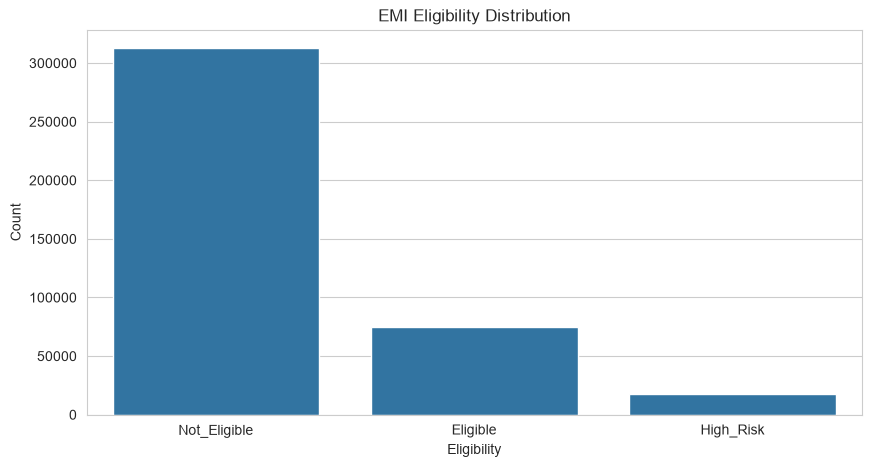

In [3]:
sns.countplot(data=df, x='emi_eligibility', order=df['emi_eligibility'].value_counts().index)
plt.title('EMI Eligibility Distribution')
plt.xlabel('Eligibility')
plt.ylabel('Count')
plt.show()

In [4]:
print(df['emi_scenario'].value_counts())

emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI              80942
Vehicle EMI                80942
Name: count, dtype: int64


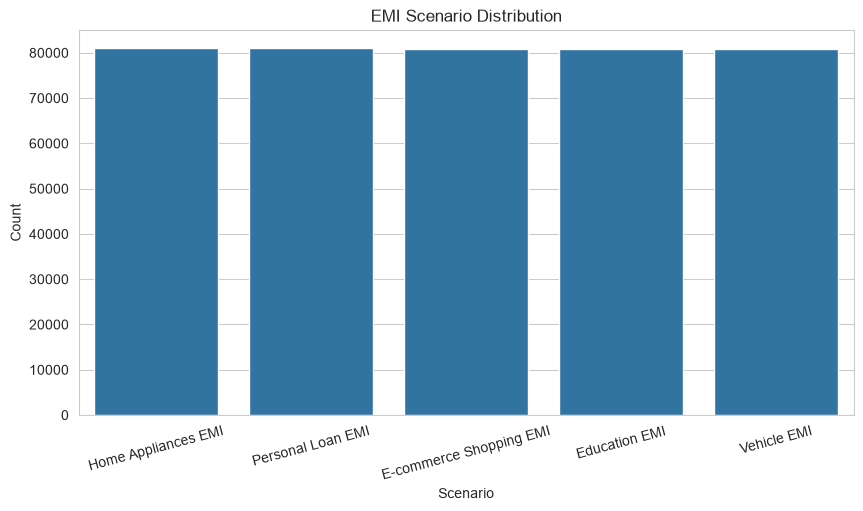

In [5]:
sns.countplot(data=df, x='emi_scenario', order=df['emi_scenario'].value_counts().index)
plt.title('EMI Scenario Distribution')
plt.xlabel('Scenario')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

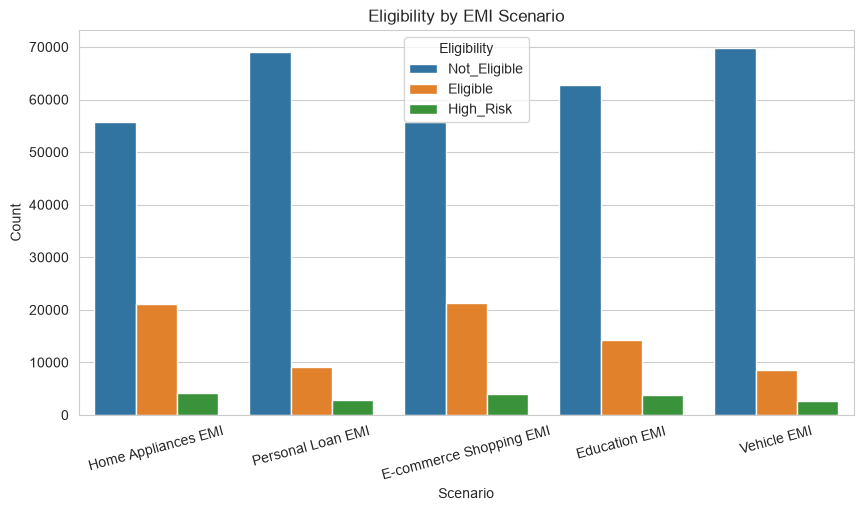

In [6]:
sns.countplot(data=df, x='emi_scenario', hue='emi_eligibility',
              order=df['emi_scenario'].value_counts().index)
plt.title('Eligibility by EMI Scenario')
plt.xlabel('Scenario')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Eligibility')
plt.show()

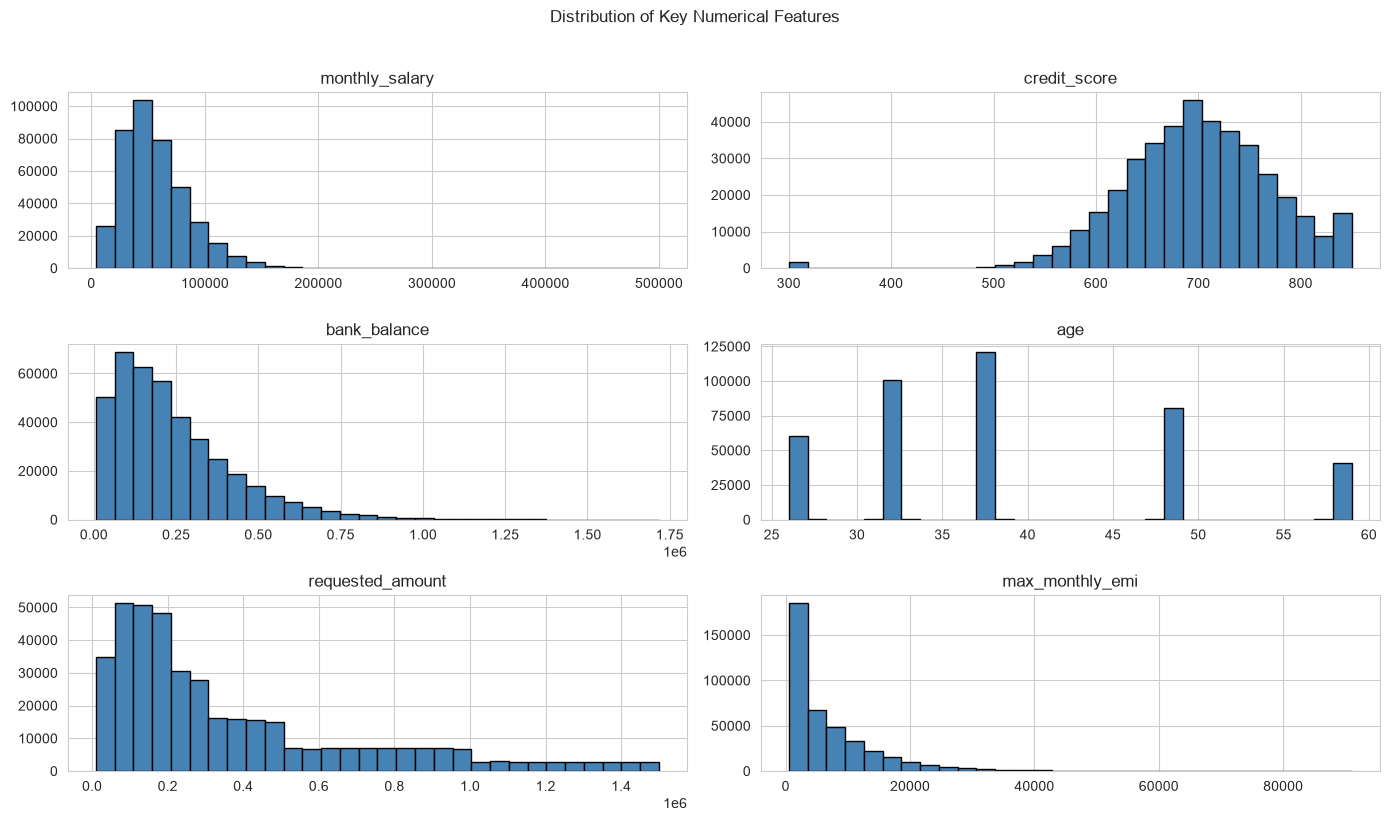

In [7]:
num_cols = ['monthly_salary', 'credit_score', 'bank_balance', 
            'age', 'requested_amount', 'max_monthly_emi']

df[num_cols].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Key Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

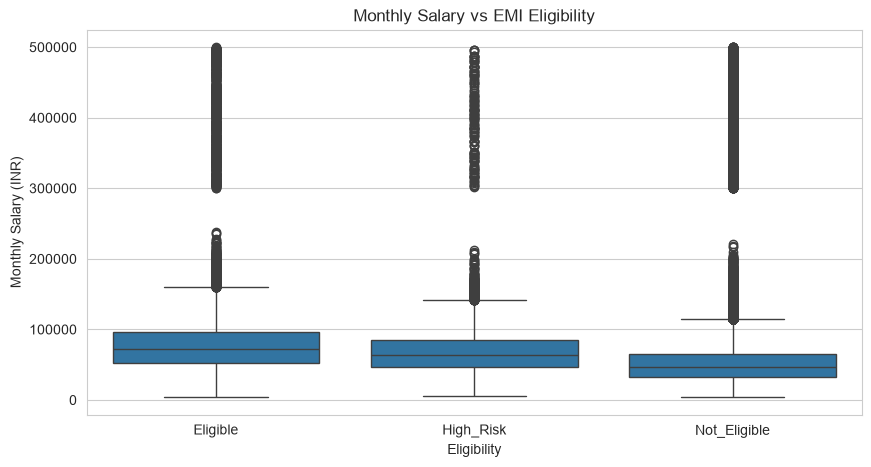

In [8]:
sns.boxplot(data=df, x='emi_eligibility', y='monthly_salary',
            order=['Eligible', 'High_Risk', 'Not_Eligible'])
plt.title('Monthly Salary vs EMI Eligibility')
plt.xlabel('Eligibility')
plt.ylabel('Monthly Salary (INR)')
plt.show()

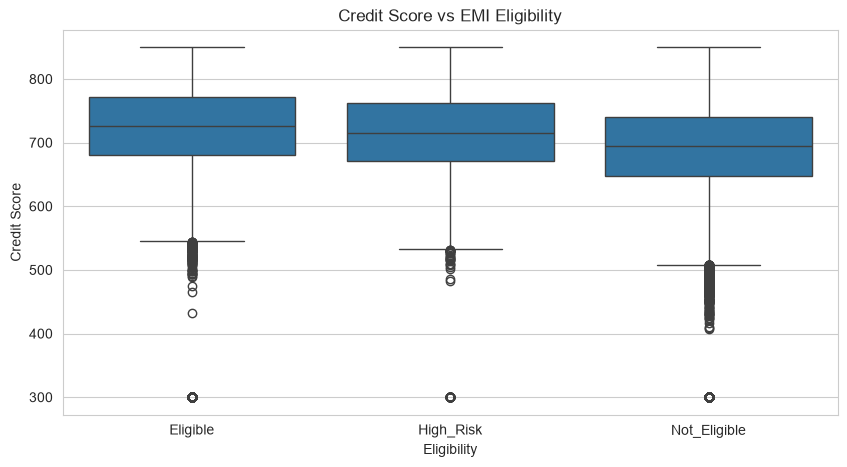

In [9]:
sns.boxplot(data=df, x='emi_eligibility', y='credit_score',
            order=['Eligible', 'High_Risk', 'Not_Eligible'])
plt.title('Credit Score vs EMI Eligibility')
plt.xlabel('Eligibility')
plt.ylabel('Credit Score')
plt.show()

In [10]:
# Valid credit score range is 300-850
print("Before clipping:")
print(df['credit_score'].describe())

df['credit_score'] = df['credit_score'].clip(300, 850)

print("\nAfter clipping:")
print(df['credit_score'].describe())

Before clipping:
count    404800.000000
mean        700.027740
std          72.950578
min         300.000000
25%         654.000000
50%         701.000000
75%         748.000000
max         850.000000
Name: credit_score, dtype: float64

After clipping:
count    404800.000000
mean        700.027740
std          72.950578
min         300.000000
25%         654.000000
50%         701.000000
75%         748.000000
max         850.000000
Name: credit_score, dtype: float64


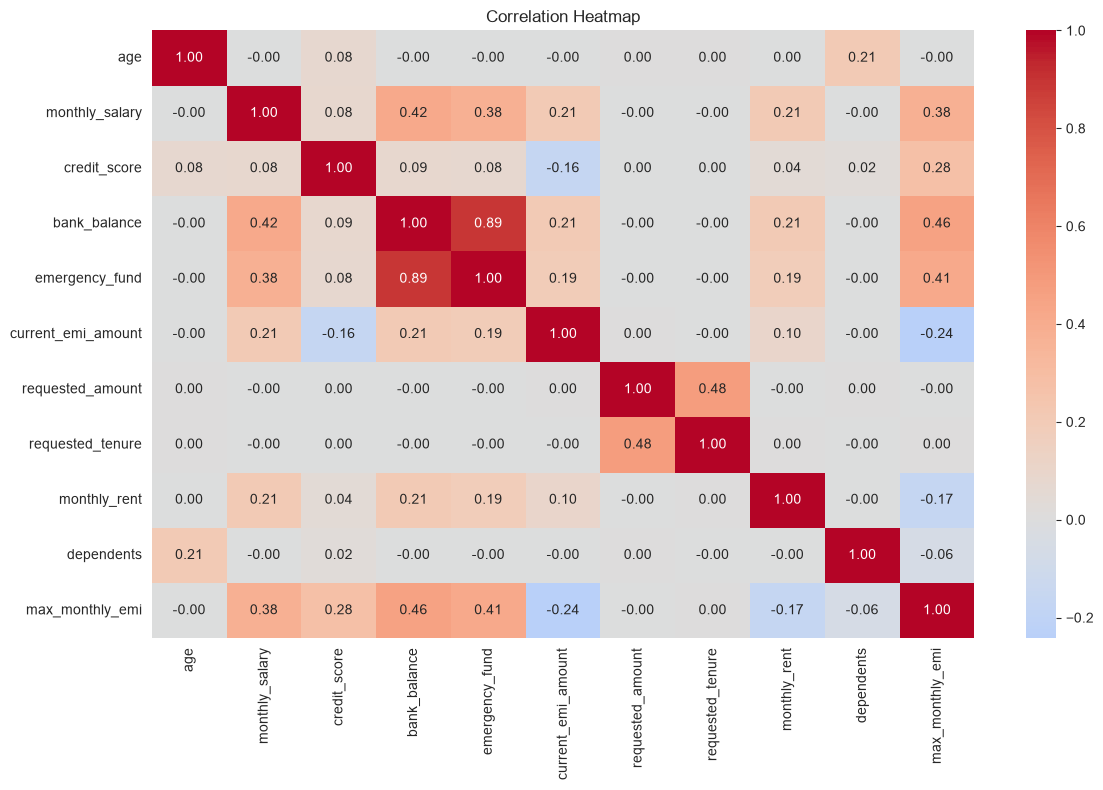

In [11]:
num_cols = ['age', 'monthly_salary', 'credit_score', 'bank_balance',
            'emergency_fund', 'current_emi_amount', 'requested_amount',
            'requested_tenure', 'monthly_rent', 'dependents', 'max_monthly_emi']

corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:
df.to_csv('data/cleaned_data.csv', index=False)
print("Updated cleaned data saved!")

Updated cleaned data saved!


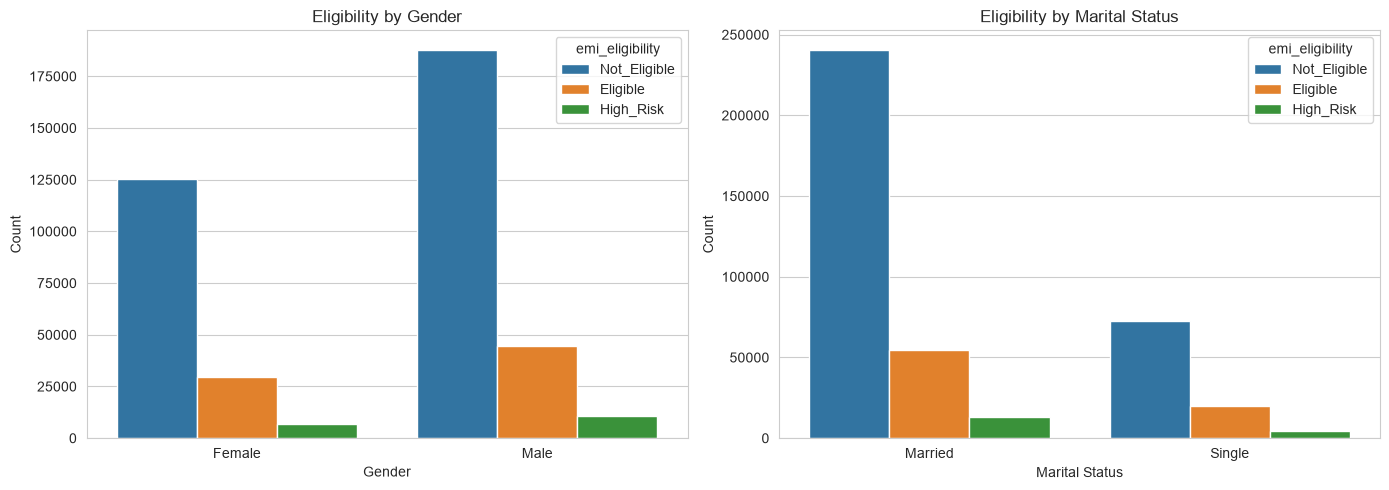

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
sns.countplot(data=df, x='gender', hue='emi_eligibility', ax=axes[0])
axes[0].set_title('Eligibility by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Marital Status
sns.countplot(data=df, x='marital_status', hue='emi_eligibility', ax=axes[1])
axes[1].set_title('Eligibility by Marital Status')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

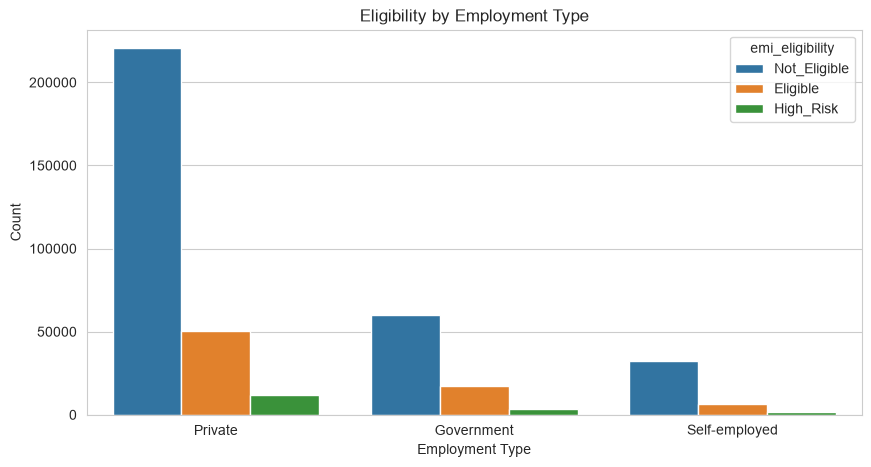

In [14]:
sns.countplot(data=df, x='employment_type', hue='emi_eligibility',
              order=df['employment_type'].value_counts().index)
plt.title('Eligibility by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.show()

In [15]:
print("=== EDA Summary ===")
print(f"Total Records: {len(df):,}")
print(f"\nEligibility Distribution:")
print(df['emi_eligibility'].value_counts(normalize=True).mul(100).round(2))
print(f"\nAvg Salary - Eligible: {df[df['emi_eligibility']=='Eligible']['monthly_salary'].median():,.0f} INR")
print(f"Avg Salary - Not_Eligible: {df[df['emi_eligibility']=='Not_Eligible']['monthly_salary'].median():,.0f} INR")
print(f"\nCredit Score range: {df['credit_score'].min():.0f} - {df['credit_score'].max():.0f}")
print(f"Max Monthly EMI range: {df['max_monthly_emi'].min():.0f} - {df['max_monthly_emi'].max():.0f} INR")

=== EDA Summary ===
Total Records: 404,800

Eligibility Distribution:
emi_eligibility
Not_Eligible    77.29
Eligible        18.39
High_Risk        4.32
Name: proportion, dtype: float64

Avg Salary - Eligible: 72,600 INR
Avg Salary - Not_Eligible: 47,100 INR

Credit Score range: 300 - 850
Max Monthly EMI range: 500 - 91040 INR
